<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-JeremyDail/blob/main/18_Simulating_random_processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 18: Simulating Random Processes

## Learning Objectives
By the end of this module you should be able to:
1. Use NumPy's modern `default_rng` interface to generate random integers, uniform floats, and random choices
2. Implement a 1D random walk with an explicit loop and explain the performance bottleneck
3. Progressively vectorize the random walk using pre-generated arrays and `np.cumsum`
4. Extend to $N$ simultaneous particles using a 2D NumPy array
5. Analyze the ensemble statistically: plot trajectories, the final-position distribution, and the mean-squared displacement

---

## Background

Random processes appear throughout physics — coin flips, Brownian motion, radioactive decay, Monte Carlo integration. The **1D random walk** is the simplest model: at each time step a particle hops left ($-1$) or right ($+1$) with equal probability. Despite its simplicity it captures fundamental statistics: after $N$ steps the position distribution converges to a Gaussian with standard deviation $\sigma = \sqrt{N}$, and the mean-squared displacement grows as

$$\langle x^2 \rangle = N.$$

Simulating many particles at once requires generating huge numbers of random values quickly. You will see how replacing Python loops with NumPy array operations gives $\sim\!100\times$ speedups.

---

## Section 0: NumPy Random Number Generation

NumPy provides two interfaces for random numbers. The **legacy** interface uses module-level functions (`np.random.randint`, `np.random.uniform`, …). The **modern** interface (NumPy ≥ 1.17) uses a *generator object* created by `np.random.default_rng()`.

| Task | Legacy | Modern (`rng`) |
|---|---|---|
| Random integers | `np.random.randint(lo, hi, N)` | `rng.integers(lo, hi, N)` |
| Uniform floats | `np.random.uniform(lo, hi, N)` | `rng.uniform(lo, hi, N)` |
| Floats in [0,1) | `np.random.random(N)` | `rng.random(N)` |
| Random choice | `np.random.choice(arr, N)` | `rng.choice(arr, N)` |
| Fix the seed | `np.random.seed(s)` | `rng = np.random.default_rng(s)` |

> **Q0.1** — What is the practical advantage of the modern `default_rng` interface over the legacy functions? (Hint: think about reproducibility and multiple independent streams.)

In [1]:
import numpy as np

# Legacy interface
ages_old = np.random.randint(35, 45, 10)
print("Legacy randint:", ages_old)

# Modern interface — create the generator ONCE, reuse it throughout
rng = np.random.default_rng()          # random seed each run
ages_new = rng.integers(35, 45, 10)
print("Modern rng    :", ages_new)

Legacy randint: [39 42 41 36 41 44 39 38 40 39]
Modern rng    : [43 35 41 37 43 38 37 35 41 35]


In [2]:
# Seeding for reproducibility
np.random.seed(10)
ages_seeded = np.random.randint(35, 45, 10)
print("Seeded legacy :", ages_seeded)

rng_fixed = np.random.default_rng(seed=42)
ages_fixed = rng_fixed.integers(35, 45, 10)
print("Seeded modern :", ages_fixed)

Seeded legacy : [44 39 35 36 44 35 36 43 44 35]
Seeded modern : [35 42 41 39 39 43 35 41 37 35]


In [3]:
# Quick demo of uniform, random, and choice
rng2 = np.random.default_rng(seed=0)
print("uniform(0,2,5) :", rng2.uniform(0, 2, 5))
print("random(5)      :", rng2.random(5))
print("choice([-1,1]) :", rng2.choice([-1, 1], 5))

uniform(0,2,5) : [1.27392337 0.53957343 0.08194705 0.03305527 1.62654048]
random(5)      : [0.91275558 0.60663578 0.72949656 0.54362499 0.93507242]
choice([-1,1]) : [-1  1  1 -1 -1]


*Your answer to Q0.1:* default_rng is better because it allows for independent random number generators with their own seeds. This improves reproducibility and prevents different parts of a program from messing with each other. The older functions used a shared global state which can lead to issues in interactions.

---

## Part 1: One-Particle 1D Random Walk

### Version 1 — Naive loop

> **Q1.1** — Complete `rw1(N)` so that at each step it draws a single random hop of $+1$ or $-1$, adds it to the current position, and appends the new position to the trajectory list.

> **Q1.2** — Time `rw1(1e4)`. If you wanted to simulate $10^4$ particles each doing $10^4$ steps with this function, estimate the total run time. Is it practical?

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def rw1(N):
    N = int(N)
    r = 0
    r_list = [r]
    rng = np.random.default_rng()
    for i in range(N):
        hop = rng.choice([-1,1])
        r += hop
        r_list.append(r)
    return r_list

CPU times: user 143 ms, sys: 4 µs, total: 143 ms
Wall time: 144 ms


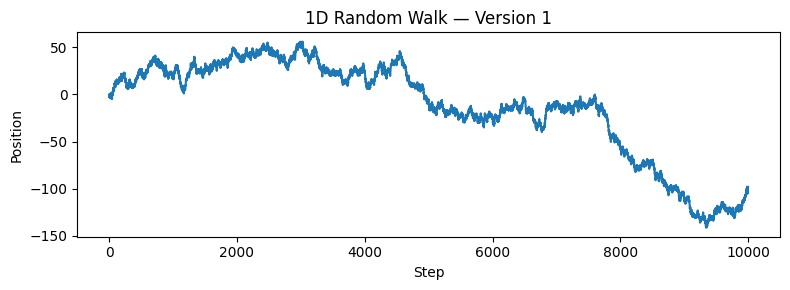

In [5]:
%time r = rw1(1e4)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.plot(r)
plt.xlabel("Step")
plt.ylabel("Position")
plt.title("1D Random Walk — Version 1")
plt.tight_layout()
plt.show()

*Your answers to Q1.1 and Q1.2:*
Q1.1: I completed rw1(N) by using rng.choice([-1,1]). This randomly chooses one hop at each step. That hop is then added to the current position in order for the new position to be appended to the trajectory list.
Q1.2: Timing rw1(1e4) gives the runtime for one particle doing 10k steps. If I needed 10^4 particles with each doing 10^4 steps, I'd need to run that about 10k times so the runtime wouldd be 10k times larger. This would be too slow to be practical.

---

### Version 2 — Pre-generate all hops

The bottleneck in `rw1` is calling `rng.choice` inside every loop iteration. We can fix that by generating **all $N$ hops at once** before the loop, then just indexing into the array inside the loop.

> **Q2.1** — Complete `rw2(N)`: generate all `N` hops with a **single** `rng.choice` call, then accumulate position in a loop as before.

> **Q2.2** — Time `rw2(1e4)` and compare with `rw1`. Why is `rw2` faster even though it still contains a for loop?

In [6]:
def rw2(N):
    N = int(N)
    r = 0
    r_list = [r]
    rng = np.random.default_rng()
    hop_list = rng.choice([-1 , 1], N)
    for i in range(N):
        r += hop_list[i]
        r_list.append(r)
    return r_list

In [7]:
%time r1 = rw1(1e4)
%time r2 = rw2(1e4)

CPU times: user 102 ms, sys: 7.14 ms, total: 109 ms
Wall time: 103 ms
CPU times: user 2.29 ms, sys: 0 ns, total: 2.29 ms
Wall time: 2.26 ms


*Your answers to Q2.1 and Q2.2:*
Q2.1: All N hops were generated at once using rng.choice([-1,1] , N) and then looped to accumulate position.
Q2.2: rw2 is faster than rw1 because it calls on the random number generator once instead of once per step. The loop is still there but the repeated random draws inside the loop have been removed.

---

### Version 3 — Fully vectorized with `np.cumsum`

`np.cumsum` computes the running total of an array:

```python
np.cumsum([1, 2, 3, 4, 5])  # → [1, 3, 6, 10, 15]
```

Applied to a hop array, it gives the position at every step without any Python loop.

> **Q3** — Complete `rw3(N)`: generate all hops with one `rng.choice` call, then compute the entire trajectory with `np.cumsum` — no loop needed.

> **Q3b** — Time all three versions for $N = 10^4$. By roughly what factor does each successive version improve on the previous?

In [8]:
print(np.cumsum([1, 2, 3, 4, 5]))

[ 1  3  6 10 15]


In [9]:
def rw3(N):
    N = int(N)
    rng = np.random.default_rng()
    hop_list = rng.choice([-1, 1], N)
    r_list = np.cumsum(hop_list)
    return r_list

In [10]:
%time r1 = rw1(1e4)
%time r2 = rw2(1e4)
%time r3 = rw3(1e4)

CPU times: user 94.6 ms, sys: 7.16 ms, total: 102 ms
Wall time: 97 ms
CPU times: user 1.74 ms, sys: 18 µs, total: 1.76 ms
Wall time: 1.72 ms
CPU times: user 172 µs, sys: 0 ns, total: 172 µs
Wall time: 175 µs


*Your answers to Q3 and Q3b:*
Q3: rw3(N) was completed by generating all hops in one call and then using np.cumsum(hop_list) to compute the trajectory without a loop.
Q3b: Each version should be faster than the previous one. rw2 improves on rw1 by reducing repeated number calls. rw3 improves by replacing the accumulation loop wit NumPy's cumulative sum. rw3 should be fastest, then rw2, then rw1

---

## Part 2: N-Particle Random Walk

### Version 1 — Loop over particles

> **Q4** — Complete `rw_multi1(Nstep, Np)`: loop over `Np` particles; for each one, generate `Nstep` hops and compute the trajectory using `np.cumsum`. Append each trajectory to `r_list`.

> **Q4b** — Plot 20 individual trajectories. Do they look qualitatively different from a single walk?

In [11]:
def rw_multi1(Nstep, Np):
    Nstep = int(Nstep)
    Np    = int(Np)
    rng    = np.random.default_rng()
    r_list = []
    for i in range(Np):
        hop_list = rng.choice([-1, 1], Nstep)
        r_list.append(np.cumsum(hop_list))
    return r_list

%time rmulti1 = rw_multi1(Nstep=1e3, Np=1e4)

CPU times: user 220 ms, sys: 21.8 ms, total: 242 ms
Wall time: 244 ms


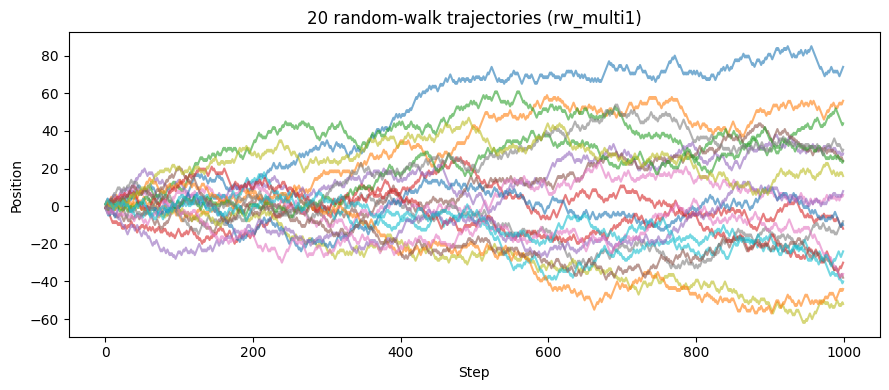

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
for i in range(20):
    plt.plot(rmulti1[i], alpha=0.6)
plt.xlabel("Step")
plt.ylabel("Position")
plt.title("20 random-walk trajectories (rw_multi1)")
plt.tight_layout()
plt.show()

*Your answers to Q4 and Q4b:*
Q4: rw_multi1(Nstep, Np) was completed by looping over particles and generating Nstep hops for each particles with the code in line 7. Then it stored np.cumsum(hop_list) for each trajectory.
Q4b: The 20 trajectories look like random zigging paths that look like a single random walk, but now there are many different possible outcomes at once. They are not different in behavior, merely different versions of the same process.

---

### Version 2 — Fully vectorized 2D

Instead of looping over particles, generate a 2D array of shape `(Np, Nstep)` all at once.  
Then `np.cumsum(hop_array, axis=1)` applies the cumulative sum **along each row** (i.e., along the steps axis), giving every trajectory simultaneously.

> **Q5** — Complete `rw_multi2(Nstep, Np)`: generate all `Np * Nstep` hops in a single `rng.choice` call shaped `[Np, Nstep]`, then apply `np.cumsum(..., axis=1)`. Why must `axis=1` be used rather than `axis=0`?

In [13]:
def rw_multi2(Nstep, Np):
    Nstep = int(Nstep)
    Np    = int(Np)
    rng   = np.random.default_rng()
    hop_array = rng.choice([-1, 1], size=(Np, Nstep))
    r_list    = np.cumsum(hop_array, axis=1)
    return r_list

%time rmulti1 = rw_multi1(Nstep=1e3, Np=1e4)
%time rmulti2 = rw_multi2(Nstep=1e3, Np=1e4)

CPU times: user 235 ms, sys: 19.7 ms, total: 255 ms
Wall time: 262 ms
CPU times: user 37.8 ms, sys: 26.9 ms, total: 64.7 ms
Wall time: 64.5 ms


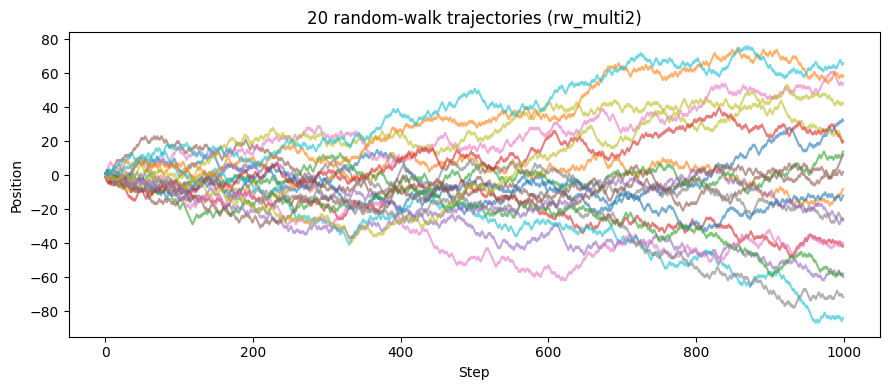

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
for i in range(20):
    plt.plot(rmulti2[i], alpha=0.6)
plt.xlabel("Step")
plt.ylabel("Position")
plt.title("20 random-walk trajectories (rw_multi2)")
plt.tight_layout()
plt.show()

*Your answer to Q5:*
rw_multi2 was completed by creating one 2D array of hops with shape (Np,Nstep) and then applying np.cumsum(... , axis=1) to get the trajectory of each particle. Using axis=1 is necessary because each row represents one particle and the columns are time steps. Using axis=0 would incorrectly accumulate across different particles instead of along time for each.

---

## Part 3: Statistical Analysis

### Task 6 — Final-position distribution

After `Nstep` steps, the position of each particle is `rmulti2[:, -1]` (the last column).

> **Q6** — Plot a normalized histogram of the final positions using `plt.hist(..., bins=40, density=True)`. Use `Nstep=1000, Np=10000`.

> **Q7** — What well-known probability distribution does the histogram resemble? What are its expected mean and standard deviation in terms of `Nstep`?

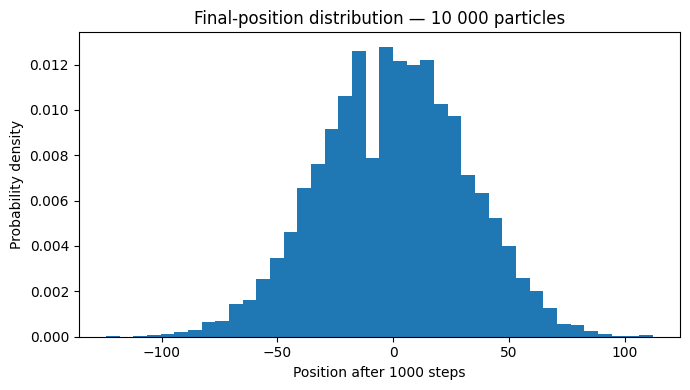

In [15]:
rmulti2 = rw_multi2(Nstep=1000, Np=10000)

plt.figure(figsize=(7, 4))
plt.hist(rmulti2[:, -1], bins=40, density=True)
plt.xlabel("Position after 1000 steps")
plt.ylabel("Probability density")
plt.title("Final-position distribution — 10 000 particles")
plt.tight_layout()
plt.show()

*Your answers to Q6 and Q7:*
Q6: I plotted the final positions using rmulti2[: , -1]. This selects the last position of each particle after 1000 steps.
Q7: The histogram should look like a Gaussian distribution. The expected mean is 0, and the expected stan dev is sqrt(Nstep). for Nstep= 1000, that is about 31.6

---

### Task 7 — Mean-Squared Displacement

The **mean-squared displacement (MSD)** at step $n$ is

$$\text{MSD}(n) = \langle x^2(n) \rangle = \frac{1}{N_p}\sum_{i=1}^{N_p} x_i^2(n)$$

> **Q8** — Compute `MSD` using `np.mean(rmulti2**2, axis=0)` and plot it vs step number.  
> What does `axis=0` average over here?

> **Q9** — Replot on a **log-log scale**. What slope do you expect, and what slope do you measure?  
> What physical quantity does the proportionality constant correspond to?

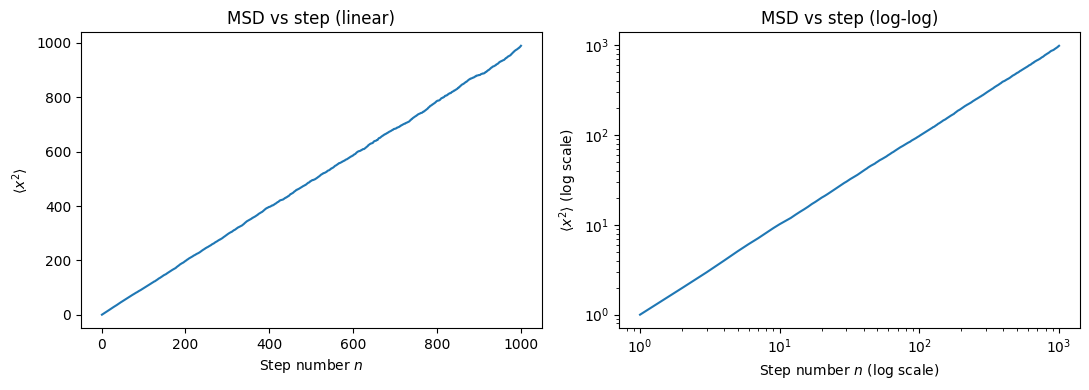

In [16]:
MSD = np.mean(rmulti2**2, axis=0)
steps = np.arange(1, 1001)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(steps, MSD)
ax1.set_xlabel("Step number $n$")
ax1.set_ylabel(r"$\langle x^2 \rangle$")
ax1.set_title("MSD vs step (linear)")

ax2.loglog(steps, MSD)
ax2.set_xlabel("Step number $n$ (log scale)")
ax2.set_ylabel(r"$\langle x^2 \rangle$ (log scale)")
ax2.set_title("MSD vs step (log-log)")

plt.tight_layout()
plt.show()

*Your answers to Q8 and Q9:*
Q8: Computed is the mean-squared displacement. Here, axis=0 means all particles are being averaged over at each step.
Q9: On a log-log plot, I'd expect the MSD to scale like n^1, so the slope should be roughly 1. That is because for a simple random walk, the mean squared displacement grows linearly with either time or step number. Proportionality constant corresponds to the diffusion behavior in the system. In continuous form its related to the diffusion coefficient D.

---

## Summary Questions

> **S1** — Summarize the three single-particle random-walk versions. For each, identify what is vectorized and what (if anything) remains a Python loop.


> **S2** — How would you modify `rw3` (or `rw_multi2`) to simulate a **2D** random walk where each step moves in $x$ **or** $y$ (four choices: $+x, -x, +y, -y$)?

> **S3** — The MSD of a random walk grows as $\langle x^2 \rangle = 2Dt$ in continuous time. Given a step size $a$ and time step $\tau$, what is the diffusion coefficient $D$ in terms of $a$ and $\tau$?

> **S4** — `rw_multi2` generates `Np * Nstep` random numbers in one call. For `Np=10000, Nstep=1000`, how many is that? Why is generating them all at once so much faster than one at a time?

*Your answers:*

**S1:** rw1 uses a python loop and generates one random hop at a time inside the loop, so nothing is vectorized. rw2 still uses a pyton loop, but it vectorizes te randon number generation by producing all hops at once. rw3 vectorizes both the random hop and the running sum using np.cumsum, so there is no loop left in the trajectory calculation.

**S2:** To simulate a 2D random walk, I'd let each step be one of four vectors: (1,0), (-1,0), (0,1) , (0,-1). Then I'd choose randomly from those four options and apply np.cumsum separately to the x and y. For a lot of particles, I could store the steps in a 3D array and take the cumsum along the steps axis.

**S3:** For a random walk with a step size and and a time step t, the diffusion coefficient is
D= a**2/2t

**S4:** For Np=10000 and Nstep = 1000, the total number of random numbers is 10000 x 1000 = 10000000. Generating them all at once is faster because NumPy does the work in optimized code instead of calling repeatedly for one number at a time.